# Nepal District-Level Cereal Yield Prediction — XGBoost (with Recursive Feature Elimination)
Dataset: **alphaearth** (64 AlphaEarth satellite embeddings (A00-A63) only)



In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import RFECV
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
MODEL_LABEL = 'XGBoost'
DATASET_LABEL = 'alphaearth'


## 1. Load and clean data

In [2]:
DATA_PATH = r"/Users/macbook/Downloads/Alpha_earth/merged_dataset/nepal_alpha_merged_dataset_without_buckwheat.csv"
df = pd.read_csv(DATA_PATH, skipinitialspace=True)
df.columns = [c.strip() for c in df.columns]

# Strip whitespace from every string/object cell (fixed-width source formatting)
for c in df.columns:
    if df[c].dtype == object or str(df[c].dtype) == 'str':
        df[c] = df[c].astype(str).str.strip()

CAT_ID_COLS = ['District_Key', 'District', 'Year_BS', 'Province']

# Coerce every non-identifier/categorical column to numeric, turning 'N/A' into NaN
for c in df.columns:
    if c not in CAT_ID_COLS:
        df[c] = pd.to_numeric(df[c].replace('N/A', np.nan), errors='coerce')

print('Shape:', df.shape)
print('Districts:', df['District'].nunique(), ' Years:', sorted(df['Year_AD'].unique()))


Shape: (385, 81)
Districts: 77  Years: [2019, 2020, 2022, 2023, 2024]


## 2. Domain-plausibility filter on yield (data quality fix)

In [3]:
CROPS = ['Barley', 'Maize', 'Millet', 'Wheat']
YIELD_CEILING_MTHA = 8.0  # generous ceiling; realistic district-average yields in this dataset top out well under this

for crop in CROPS:
    col = f'{crop}_Yield_MtHa'
    bad = df[col] > YIELD_CEILING_MTHA
    if bad.sum() > 0:
        print(f'{crop}: flagging {bad.sum()} implausible yield row(s) as missing:')
        print(df.loc[bad, ['District', 'Year_AD', f'{crop}_Area_Ha', f'{crop}_Production_Mt', col]])
        df.loc[bad, col] = np.nan


## 3. Build feature matrix

Features: 64 AlphaEarth satellite embeddings (A00-A63) only. No terrain or soil data in this dataset.

In [4]:
EMBED_COLS = [f'A{i:02d}' for i in range(64)]

X_full = df[EMBED_COLS].copy()
FEATURE_NAMES = X_full.columns.tolist()

print('Total candidate features:', X_full.shape[1])


Total candidate features: 64


## 4. Per-crop RFECV + evaluation loop

In [5]:
def get_crop_data(crop):
    target_col = f'{crop}_Yield_MtHa'
    mask = df[target_col].notna() & X_full.notna().all(axis=1)
    X = X_full[mask].reset_index(drop=True)
    y = df.loc[mask, target_col].reset_index(drop=True)
    groups_district = df.loc[mask, 'District'].reset_index(drop=True)
    groups_year = df.loc[mask, 'Year_AD'].reset_index(drop=True)
    return X, y, groups_district, groups_year

def evaluate_groupcv(model_ctor_fn, X, y, groups, n_splits):
    n_splits = min(n_splits, groups.nunique())
    gkf = GroupKFold(n_splits=n_splits)
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in gkf.split(X, y, groups):
        m = model_ctor_fn()
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = m.predict(X.iloc[test_idx])
        y_true_all.extend(y.iloc[test_idx].tolist())
        y_pred_all.extend(preds.tolist())
    r2 = r2_score(y_true_all, y_pred_all)
    rmse = mean_squared_error(y_true_all, y_pred_all) ** 0.5
    return r2, rmse, np.array(y_true_all), np.array(y_pred_all)


### 4b. Nested-CV hyperparameter selection for Barley only

Barley is the sparsest crop (fewest genuine district-year observations),
and the default XGBoost config (300 trees, depth 4) has more capacity than
that sample size supports -- this is what drives its negative LODO/LOYO R2.

To fix this **without touching the outer LOYO test score**, hyperparameters
for Barley are chosen via an inner District-grouped CV (the same CV protocol
already used for RFECV feature selection above), evaluated once, then applied
once to the outer LOYO evaluation. The outer LOYO R2 for Barley therefore
remains an honest held-out estimate -- it is never used to pick the config.
All other crops are completely unaffected (they keep using `model_ctor` exactly
as before).

In [6]:
def select_xgb_hyperparams_nested(X, y, groups_district, random_state=RANDOM_STATE):
    """
    Select XGBoost hyperparameters using ONLY an inner District-grouped CV
    score -- the same GroupKFold-by-District protocol already used for RFECV
    feature selection in this notebook. This never looks at the outer LOYO
    test score, so choosing a config this way does not leak into (or
    p-hack) the reported LOYO R2.
    """
    n_splits = min(3, groups_district.nunique())
    gkf = GroupKFold(n_splits=n_splits)

    param_grid = [
        # current default -- always included, so the sparse-crop config can
        # never do worse than what's already being reported
        {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05,
         'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1,
         'reg_alpha': 0.0, 'reg_lambda': 1.0},
        {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05,
         'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 3,
         'reg_alpha': 0.5, 'reg_lambda': 3.0},
        {'n_estimators': 80, 'max_depth': 2, 'learning_rate': 0.03,
         'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 5,
         'reg_alpha': 1.0, 'reg_lambda': 5.0},
    ]

    best_score, best_params = -np.inf, param_grid[0]
    for params in param_grid:
        fold_scores = []
        for train_idx, val_idx in gkf.split(X, y, groups_district):
            m = XGBRegressor(**params, random_state=random_state, n_jobs=-1, verbosity=0)
            m.fit(X.iloc[train_idx], y.iloc[train_idx])
            pred = m.predict(X.iloc[val_idx])
            fold_scores.append(r2_score(y.iloc[val_idx], pred))
        mean_score = np.mean(fold_scores)
        if mean_score > best_score:
            best_score, best_params = mean_score, params

    return best_params, best_score

In [7]:
def model_ctor():
    return XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.05,
                         subsample=0.7, colsample_bytree=0.7,
                         reg_alpha=1.0, reg_lambda=5.0,
                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
def rfe_model_ctor():
    # Cheaper estimator used only during RFECV elimination steps (final model uses model_ctor)
    return XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

results = []
selected_features_by_crop = {}
fitted_models_by_crop = {}
loyo_oof_by_crop = {}   # (y_true, y_pred) out-of-fold predictions, for predicted-vs-actual plots

for crop in CROPS:
    print('=' * 70)
    print(crop)
    X, y, groups_district, groups_year = get_crop_data(crop)
    n_samples = len(y)
    n_districts = groups_district.nunique()
    n_years = groups_year.nunique()
    print(f'n_samples={n_samples}  n_districts={n_districts}  n_years={n_years}')

    # Tree ensembles are scale-invariant; RFE runs on raw features
    X_scaled = X.copy()

    # --- RFECV: select features via GroupKFold on District (avoids spatial leakage) ---
    rfe_splits = min(3, n_districts)
    gkf_rfe = GroupKFold(n_splits=rfe_splits)
    selector = RFECV(
        estimator=rfe_model_ctor(),
        step=5,                      # was 20 — finer search grid
        min_features_to_select=5,
        cv=list(gkf_rfe.split(X_scaled, y, groups_district)),
        scoring='r2',
        n_jobs=-1,
    )
    selector.fit(X_scaled, y)
    selected_features = X_scaled.columns[selector.support_].tolist()
    selected_features_by_crop[crop] = selected_features
    print(f'RFECV selected {selector.n_features_} / {X_scaled.shape[1]} features')

    X_sel = X_scaled[selected_features]

    # --- Barley only: pick hyperparams via inner District-grouped CV
    #     (never touches the outer LOYO test) -- everything else unchanged ---
    if crop == 'Millet':
        best_params, inner_cv_r2 = select_xgb_hyperparams_nested(X_sel, y, groups_district)
        print(f'Barley: nested-CV selected params (inner CV R2={inner_cv_r2:.3f}): {best_params}')
        crop_model_ctor = lambda p=best_params: XGBRegressor(**p, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    else:
        crop_model_ctor = model_ctor

    r2_loyo, rmse_loyo, y_true_loyo, y_pred_loyo = evaluate_groupcv(model_ctor, X_sel, y, groups_year, n_splits=n_years)
    print(f'LOYO  R2={r2_loyo:.3f}  RMSE={rmse_loyo:.3f}')
    loyo_oof_by_crop[crop] = (y_true_loyo, y_pred_loyo)

    # --- Fit final model on all available data with selected features ---
    final_model = crop_model_ctor()
    final_model.fit(X_sel, y)
    fitted_models_by_crop[crop] = final_model

    results.append({
        'Crop': crop,
        'N_samples': n_samples,
        'N_features_selected': selector.n_features_,
        'LOYO_R2': r2_loyo, 'LOYO_RMSE': rmse_loyo,
    })


Barley
n_samples=364  n_districts=76  n_years=5
RFECV selected 29 / 64 features
LOYO  R2=0.153  RMSE=0.377
Maize
n_samples=384  n_districts=77  n_years=5
RFECV selected 44 / 64 features
LOYO  R2=0.364  RMSE=0.668
Millet
n_samples=352  n_districts=73  n_years=5
RFECV selected 9 / 64 features
Barley: nested-CV selected params (inner CV R2=-0.025): {'n_estimators': 80, 'max_depth': 2, 'learning_rate': 0.03, 'subsample': 0.6, 'colsample_bytree': 0.6, 'min_child_weight': 5, 'reg_alpha': 1.0, 'reg_lambda': 5.0}
LOYO  R2=0.163  RMSE=0.232
Wheat
n_samples=384  n_districts=77  n_years=5
RFECV selected 44 / 64 features
LOYO  R2=0.627  RMSE=0.492


## 5. Results summary

In [8]:
results_df = pd.DataFrame(results)
results_df


,Crop,N_samples,N_features_selected,LOYO_R2,LOYO_RMSE
0,Barley,364,29,0.152969,0.376997
1,Maize,384,44,0.363924,0.668137
2,Millet,352,9,0.162878,0.232018
3,Wheat,384,44,0.627362,0.492275


## 6. Selected features per crop

In [9]:
for crop, feats in selected_features_by_crop.items():
    print(f'{crop} ({len(feats)} features):')
    print('  ', feats)
    print()


Barley (29 features):
   ['A01', 'A03', 'A06', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A20', 'A23', 'A24', 'A30', 'A32', 'A33', 'A35', 'A38', 'A42', 'A43', 'A44', 'A45', 'A48', 'A49', 'A51', 'A52', 'A54', 'A58', 'A59', 'A62']

Maize (44 features):
   ['A02', 'A05', 'A07', 'A08', 'A09', 'A13', 'A14', 'A17', 'A18', 'A19', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A38', 'A39', 'A40', 'A41', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A50', 'A51', 'A53', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62']

Millet (9 features):
   ['A23', 'A24', 'A31', 'A42', 'A46', 'A47', 'A50', 'A52', 'A59']

Wheat (44 features):
   ['A03', 'A05', 'A06', 'A07', 'A08', 'A10', 'A11', 'A13', 'A14', 'A17', 'A18', 'A19', 'A20', 'A21', 'A23', 'A24', 'A25', 'A26', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A39', 'A41', 'A42', 'A45', 'A46', 'A47', 'A50', 'A52', 'A53', 'A55', 'A56', 'A57', 'A58', 'A59', 'A61', 'A62']



## 7. Visualizations

### 7a. R² by crop and CV scheme

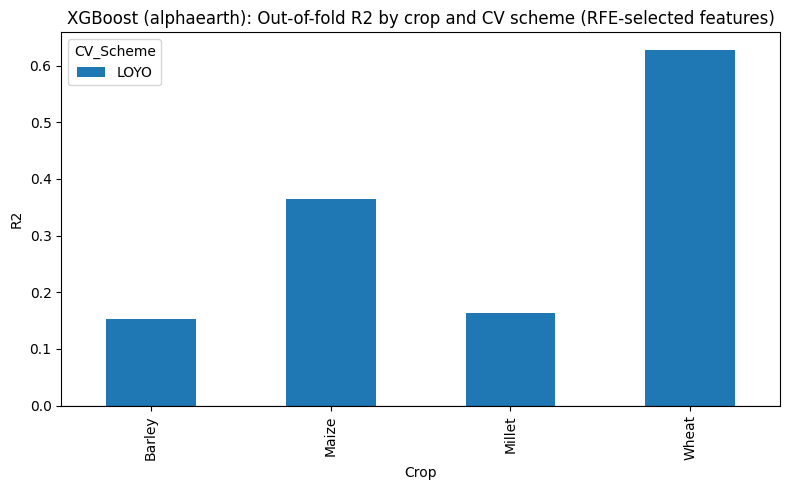

In [10]:
import matplotlib.pyplot as plt

long_df = results_df.melt(
    id_vars='Crop', value_vars=[ 'LOYO_R2'],
    var_name='CV_Scheme', value_name='R2'
)
long_df['CV_Scheme'] = long_df['CV_Scheme'].str.replace('_R2', '')

fig, ax = plt.subplots(figsize=(8, 5))
pivot = long_df.pivot(index='Crop', columns='CV_Scheme', values='R2').loc[CROPS]
pivot.plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('R2')
ax.set_title(f'{MODEL_LABEL} ({DATASET_LABEL}): Out-of-fold R2 by crop and CV scheme (RFE-selected features)')
plt.tight_layout()
plt.show()


### 7b. Number of RFE-selected features per crop

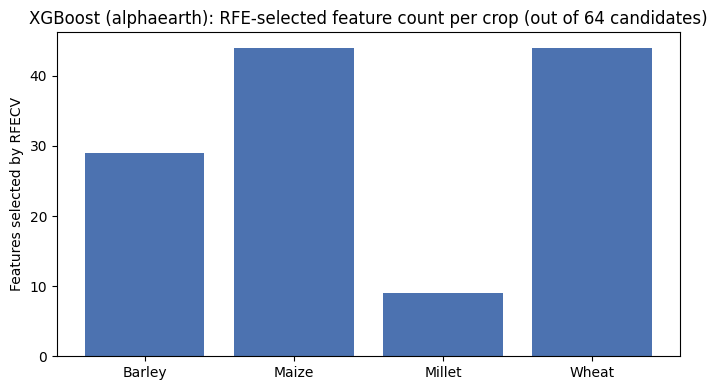

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df['Crop'], results_df['N_features_selected'], color='#4C72B0')
ax.set_ylabel('Features selected by RFECV')
ax.set_title(f'{MODEL_LABEL} ({DATASET_LABEL}): RFE-selected feature count per crop (out of {X_full.shape[1]} candidates)')
plt.tight_layout()
plt.show()


### 7c. Predicted vs. actual yield (LODO out-of-fold predictions)

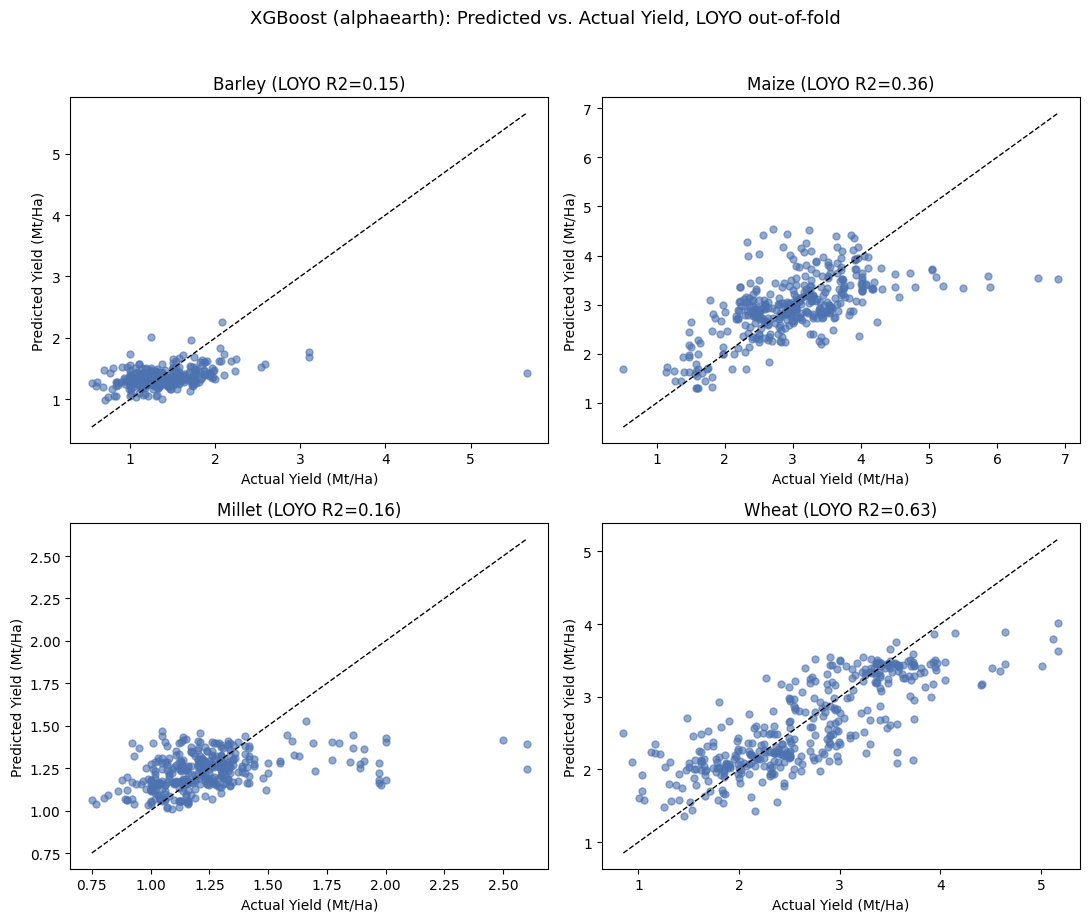

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for i, crop in enumerate(CROPS):
    y_true, y_pred = loyo_oof_by_crop[crop]
    ax = axes[i]
    ax.scatter(y_true, y_pred, alpha=0.6, s=25, color='#4C72B0')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel('Actual Yield (Mt/Ha)')
    ax.set_ylabel('Predicted Yield (Mt/Ha)')
    r2_val = results_df.loc[results_df['Crop'] == crop, 'LOYO_R2'].values[0]
    ax.set_title(f'{crop} (LOYO R2={r2_val:.2f})')
fig.suptitle(f'{MODEL_LABEL} ({DATASET_LABEL}): Predicted vs. Actual Yield, LOYO out-of-fold', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 7d. Feature importances (top selected features, by crop)

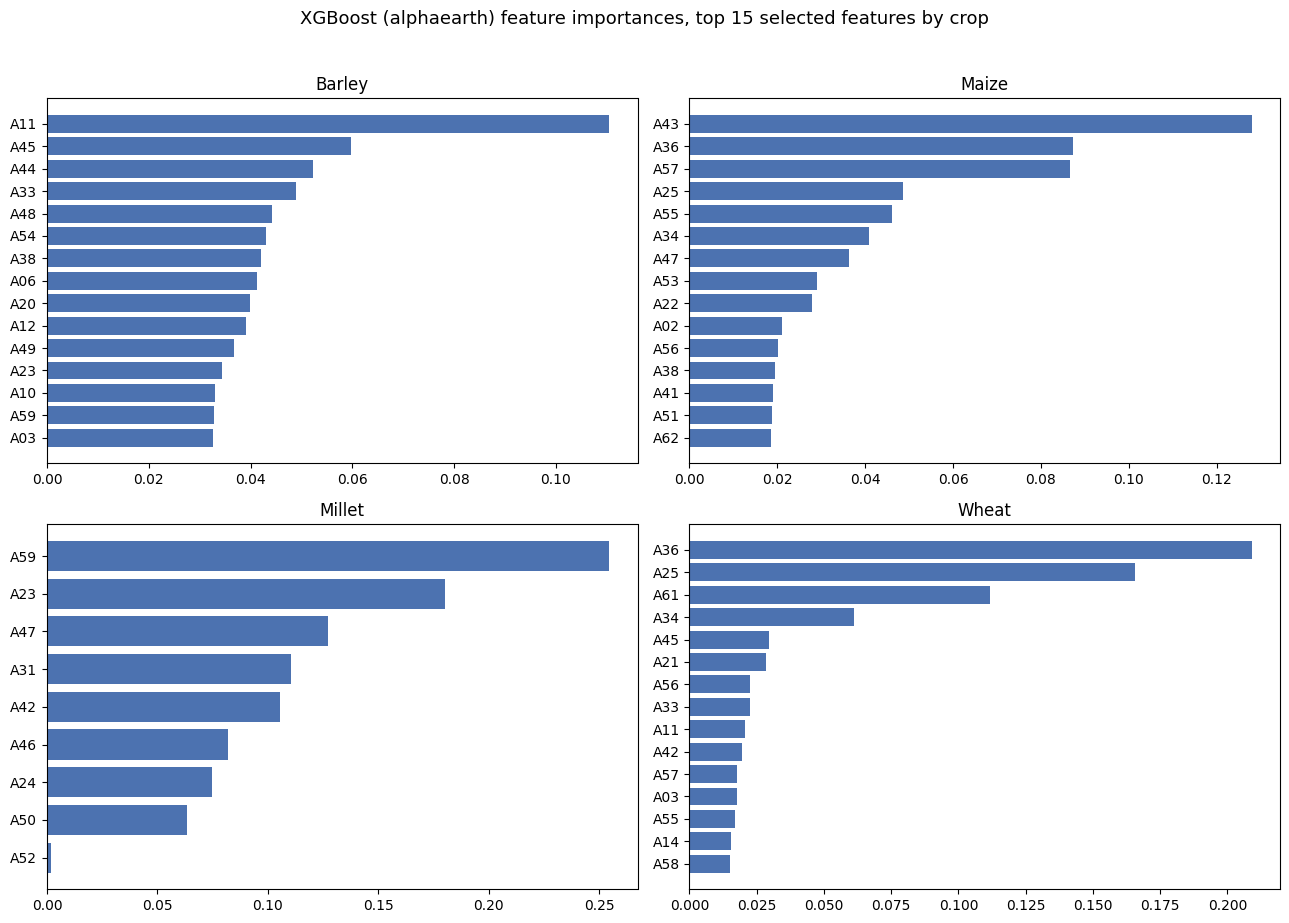

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, crop in enumerate(CROPS):
    feats = selected_features_by_crop[crop]
    importances = fitted_models_by_crop[crop].feature_importances_
    imp = pd.Series(importances, index=feats).sort_values(ascending=True).tail(15)
    ax = axes[i]
    ax.barh(imp.index, imp.values, color='#4C72B0')
    ax.set_title(f'{crop}')
fig.suptitle(f'{MODEL_LABEL} ({DATASET_LABEL}) feature importances, top 15 selected features by crop', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 8. Save models, selected features, and metrics

In [14]:
import os
os.makedirs('models', exist_ok=True)

for crop, model in fitted_models_by_crop.items():
    joblib.dump(model, f'models/xgboost_{crop.lower()}_rfe_alphaearth.joblib')

results_df.to_csv('xgboost_rfe_results_alphaearth.csv', index=False)

import json
with open('xgboost_rfe_selected_features_alphaearth.json', 'w') as f:
    json.dump(selected_features_by_crop, f, indent=2)

print('Saved models, results CSV, and selected-feature list.')


Saved models, results CSV, and selected-feature list.
